In [10]:
import argparse
import os
import pickle
import sys
import typing

import pandas as pd
import torch
from Bio import SeqIO
from typing import List, Union, Optional, Callable, Sequence
from transformers import (
    EsmForMaskedLM, 
    PretrainedConfig, 
    EsmTokenizer, 
    DataCollatorForLanguageModeling, 
    Trainer
)

from tokenizers import Tokenizer
import torch
import torch.nn.functional as F
from torch import Tensor, nn

import einops
import yaml
import sys
import json
import functools
import os
import shutil

import numpy as np
from huggingface_hub import hf_hub_download
from datasets import Dataset, load_dataset
import math
from tqdm import tqdm

from matplotlib import pyplot as plt

from jaxtyping import Bool, Float, Int

from plotly_utils import (
    imshow
)

In [2]:
import transformer_lens
import transformer_lens.utils as utils
from transformer_lens.hook_points import (
    HookedRootModule,
    HookPoint,
)

# Hooking utilities
from transformer_lens import (
    HookedTransformer,
    HookedTransformerConfig,
    FactoredMatrix,
    ActivationCache,
)

sys.path.append("../../scripts")
from compute_node_embeddings import load_sequences, get_protein_sequence
from interp_utils import get_hooked_state_dict, get_hooked_esm_config, get_logits_hooked_esm

In [3]:
from covfit_stuff.config import Config, ModelConfig
from covfit_stuff.esm_regression import load_model_for_inference, get_model_predictions
import tempfile

# Load CovFit model

In [4]:
MODEL_PATH = "TheSatoLab-UTokyo/CoVFit"
FOLD_IDS_TO_USE = [0]
TARGET_FOLD_ID = 0
OUTPUT_PREFIX = "inference_results"
model_name = "facebook/esm2_t33_650M_UR50D"

device = "cuda"
CONTEXT_LEN = 1000

In [5]:
def download_hf_checkpoints(repo_id, fold_ids):
    """
    Download specified fold checkpoint files from Hugging Face
    Hugging Faceから指定されたfoldのckptファイルをダウンロード
    
    Note: The model repository is public, so no token is required.
    注意：モデルリポジトリは公開されているため、トークンは不要です。
    """
    print(f"Downloading checkpoints from {repo_id} for folds: {fold_ids}")
    model_paths = []
    temp_dir = tempfile.mkdtemp()
    
    try:
        for fold_id in fold_ids:
            filename = f"covfit_model_20231102_{fold_id}.ckpt"
            print(f"Downloading {filename}...")
            
            # Download (no token needed for public repository)
            # ダウンロード（公開リポジトリのためトークン不要）
            downloaded_path = hf_hub_download(
                repo_id=repo_id,
                filename=filename,
                cache_dir=temp_dir
            )
            model_paths.append(downloaded_path)
            
        print(f"Successfully downloaded {len(model_paths)} checkpoint files")
        return model_paths, temp_dir
        
    except Exception as e:
        # Clean up temporary directory on failure
        # 失敗時はテンポラリディレクトリをクリーンアップ
        shutil.rmtree(temp_dir, ignore_errors=True)
        raise e

In [11]:
model_paths, temp_dir = download_hf_checkpoints(
    repo_id=MODEL_PATH,
    fold_ids=FOLD_IDS_TO_USE
)

task_dict_path = hf_hub_download(
    repo_id=MODEL_PATH,
    filename="task_id_dict.pt"
)

checkpoint = torch.load(model_paths[0], map_location=device)
final_weights = checkpoint['state_dict'] if 'state_dict' in checkpoint else checkpoint

original_task_id_infos = torch.load(task_dict_path, map_location=device)
n_targets_original = len(original_task_id_infos)

model_config = ModelConfig()
model_config.da_model_name = model_name

model = load_model_for_inference(model_paths[0], model_config, n_targets_original)
esm_fine_tuned = model.merge_and_unload() #merge PEFT adapter model with the base model and make a fully new model

# dumb thing to make hooked esm and this esm agree
esm_fine_tuned.esm.embeddings.token_dropout = False

# clean up after installing
if temp_dir and os.path.exists(temp_dir):
    shutil.rmtree(temp_dir, ignore_errors=True)
    print("Temporary files cleaned up")

Successfully downloaded 1 checkpoint files
Temporary files cleaned up


In [12]:
esm_fine_tuned = esm_fine_tuned.to(device)
esm_fine_tuned = esm_fine_tuned.eval()

In [13]:
esm_config = esm_fine_tuned.config
esm_config.token_dropout = False
esm_config.model_name = model_name

REPO_ID = esm_config.model_name
special_tokens_map_file = "special_tokens_map.json"
tokenizer_config = {}
tokenizer_config["vocab_file"] = hf_hub_download(repo_id=REPO_ID, filename="vocab.txt")
tokenizer_config["model_max_length"] = CONTEXT_LEN
with open(hf_hub_download(repo_id=REPO_ID, filename=special_tokens_map_file), "r") as f:
    tokenizer_config = {**tokenizer_config, **(json.load(f))}

In [14]:
tokenizer = EsmTokenizer(**tokenizer_config)

hooked_esm_config = get_hooked_esm_config(esm_config, context_len=CONTEXT_LEN, use_hook_tokens=True)
hooked_esm = HookedTransformer(hooked_esm_config)
print(hooked_esm.load_state_dict(get_hooked_state_dict(esm_fine_tuned.state_dict(), hooked_esm_config)))

<All keys matched successfully>


In [15]:
# clean up memory
del model

# Load data

In [16]:
def tokenizer_for_map(seq, seq_key="input_ids", tokenizer=tokenizer): #Tokenizer and params including special_tokens_mask required for MLM
    return tokenizer(
        seq[seq_key],
        return_tensors="pt", 
        return_special_tokens_mask=True,
        truncation=True,
        padding="max_length",
        max_length=300,
    )

In [17]:
# data loading
with open("../../config/pathogen_config.yaml", "r") as config_file:
    config = yaml.safe_load(config_file)
pathogens = list(config["pathogens"].keys())
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer,return_tensors='pt',mlm_probability=0.15)

# Examining perplexity

In [16]:
# small thing to turn off annoying wand questions
os.environ["WANDB_DISABLED"] = "true"
pathogen_perplexities = dict()


# Get coronaviridae ESM
# Optionally, then switch to final LoRA finetuned fitness ESM
esm_cov_state_dict_path = "../../data/covfit_model/model_ESM2_coronaviridae/pytorch_model.bin"
esm_disp = EsmForMaskedLM(esm_config).to(device)
esm_disp_state_dict = torch.load(esm_cov_state_dict_path)
# removing fixed position embedding
del esm_disp_state_dict["esm.embeddings.position_embeddings.weight"]
del esm_disp_state_dict["esm.embeddings.position_ids"]
print(esm_disp.load_state_dict(esm_disp_state_dict))
esm_disp.esm = esm_fine_tuned.esm


for pathogen_name in ["sars_cov_2_spike", "cov_229e_s1"]:
    fasta_file = f"../../data/pathogen/{pathogen_name}/alignment.fasta"
    data = load_sequences(fasta_file)
    sequence_names, sequences = list(zip(*list(data.items())))
    uniq_seqs, unique_inds = np.unique(sequences, return_index=True) # For the purpose of eval, I only care about unique sequences 


    # identical code to how it's compute_node_embeddings.py
    protein_coords = config["pathogens"][pathogen_name]["protein_coords"]
    cut_seqs = [get_protein_sequence(x, protein_coords) for x in uniq_seqs]
    cut_seqs = list(np.unique([x for x in cut_seqs if len(x) > 3])) # remove any identical sequences again in case more appear after trimming

    # create dataset
    eval_dict = {"input_ids":list(cut_seqs)}

    eval_dset = Dataset.from_dict(eval_dict)

    column_names = eval_dset.column_names #This will be the names of all the old columns, to then be deleted after the new tokenized columns are added.
    eval_dataset = eval_dset.map( 
        tokenizer_for_map,
        batched=True,
        num_proc=8,
        remove_columns=column_names,
    )

    # evaluate ESM-2 model on dataset 
    evaluator = Trainer(
      model=esm_disp,
      data_collator=data_collator,
      eval_dataset=eval_dataset,
    )
    eval_results = evaluator.evaluate()
    pathogen_perplexities[pathogen_name] = math.exp(eval_results['eval_loss'])
    print(f"Pathogen: {pathogen_name}\nESM-2 Perplexity: {pathogen_perplexities[pathogen_name]:.4f}\n")

# with open("pathogen_perplexities.json", "w") as file:
#     json.dump(pathogen_perplexities, file)

<All keys matched successfully>


Map (num_proc=8): 100%|█████████████████████████████████████████████████████████████████████| 1699/1699 [00:01<00:00, 919.46 examples/s]


{'eval_loss': 2.6886110305786133, 'eval_model_preparation_time': 0.0114, 'eval_runtime': 26.7004, 'eval_samples_per_second': 63.632, 'eval_steps_per_second': 7.977}
Pathogen: sars_cov_2_spike
ESM-2 Perplexity: 14.7112



Map (num_proc=8): 100%|██████████████████████████████████████████████████████████████████████████| 82/82 [00:01<00:00, 66.41 examples/s]


{'eval_loss': 2.6629815101623535, 'eval_model_preparation_time': 0.0115, 'eval_runtime': 1.6334, 'eval_samples_per_second': 50.202, 'eval_steps_per_second': 6.734}
Pathogen: cov_229e_s1
ESM-2 Perplexity: 14.3390



In [17]:
uniref50_ds = load_dataset("fredzzp/Uniref50", split="test")
column_names = uniref50_ds.column_names #This will be the names of all the old columns, to then be deleted after the new tokenized columns are added.
uniref_tokenizer_map = functools.partial(tokenizer_for_map, seq_key="sequence")
uniref_dataset = uniref50_ds.map( 
        uniref_tokenizer_map,
        batched=True,
        num_proc=8,
        remove_columns=column_names,
    )
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer,return_tensors='pt',mlm_probability=0.15)
os.environ["WANDB_DISABLED"] = "true"

# evaluate ESM-2 model on uniref50 
evaluator = Trainer(
  model=esm_disp,
  data_collator=data_collator,
  eval_dataset=uniref_dataset[:800]["input_ids"],
)
uniref_results = evaluator.evaluate()
pathogen_perplexities["uniref50"] = math.exp(uniref_results['eval_loss'])
print(f"Uniref50 ESM-2 Perplexity: {pathogen_perplexities['uniref50']:.4f}\n")

Map (num_proc=8): 100%|██████████████████████████████████████████████████████████████████| 48941/48941 [00:17<00:00, 2760.71 examples/s]


{'eval_loss': 2.140408992767334, 'eval_model_preparation_time': 0.0047, 'eval_runtime': 12.3947, 'eval_samples_per_second': 64.544, 'eval_steps_per_second': 8.068}
Uniref50 ESM-2 Perplexity: 8.5029



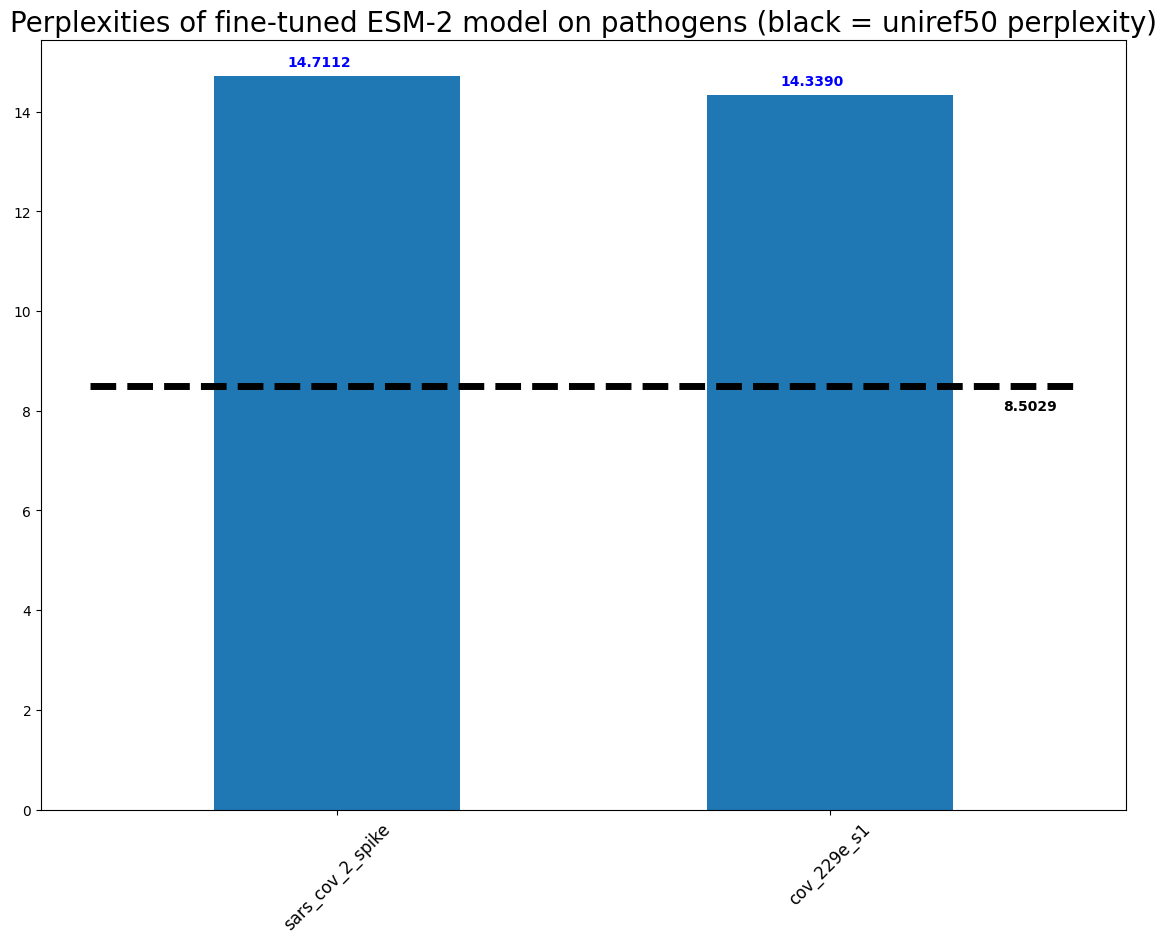

In [18]:
fig, ax = plt.subplots(1,1,figsize=(14,10))
ax.set_title("Perplexities of fine-tuned ESM-2 model on pathogens (black = uniref50 perplexity)",fontsize=20)
ax.bar(x=["sars_cov_2_spike", "cov_229e_s1"], height=[pathogen_perplexities[p] for p in ["sars_cov_2_spike", "cov_229e_s1"]], width=0.5)
ax.tick_params("x", rotation=45, labelsize=12)
ax.plot([-0.5,1.5], [pathogen_perplexities["uniref50"] for _ in range(2)], linestyle="dashed", color="black", linewidth=5)
for i,v in enumerate([pathogen_perplexities[p] for p in ["sars_cov_2_spike", "cov_229e_s1"]]):
    ax.text(i-0.1, v+0.2, f"{v:.4f}", color='blue', fontweight='bold')

ax.text(len(["sars_cov_2_spike", "cov_229e_s1"]) - 0.65, pathogen_perplexities["uniref50"] - .5, f"{pathogen_perplexities['uniref50']:.4f}", color="black", fontweight="bold")
fig.show()

# Interp seeing which attention heads impact fitness estimate the most

## Load data for interp experiment

In [18]:
pathogen_name = "cov_229e_s1"

fasta_file = f"../../data/pathogen/{pathogen_name}/alignment.fasta"
data = load_sequences(fasta_file)
sequence_names, sequences = list(zip(*list(data.items())))
uniq_seqs, unique_inds = np.unique(sequences, return_index=True) # For the purpose of eval, I only care about unique sequences 


# identical code to how it's compute_node_embeddings.py
protein_coords = config["pathogens"][pathogen_name]["protein_coords"]
cut_seqs = [get_protein_sequence(x, protein_coords) for x in uniq_seqs]
cut_seqs = list(np.unique([x for x in cut_seqs if len(x) > 3])) # remove any identical sequences again in case more appear after trimming

tok_output = tokenizer(cut_seqs, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=300)
tok_seqs = tok_output.input_ids.to(device)
tok_masks = tok_output.attention_mask.to(device)

# eval_dict = {"input_ids":list(cut_seqs)}
# eval_dset = Dataset.from_dict(eval_dict)
# column_names = eval_dset.column_names #This will be the names of all the old columns, to then be deleted after the new tokenized columns are added.
# eval_dataset = eval_dset.map( 
#     tokenizer_for_map,
#     batched=True,
#     num_proc=8,
#     remove_columns=column_names,
# )

# assert len(eval_dataset) == len(cut_seqs)

print(pathogen_name)
print(f"Number unique sequences: {len(cut_seqs)}")
print(tok_seqs.shape)

cov_229e_s1
Number unique sequences: 82
torch.Size([82, 300])


In [19]:
# add padding mask to model
def add_perma_hooks_to_mask_pad_tokens(
    model: HookedTransformer, pad_token: int
) -> HookedTransformer:
    # Hook which operates on the tokens, and stores a mask where tokens equal [pad]
    def cache_padding_tokens_mask(tokens: Float[Tensor, "batch seq"], hook: HookPoint) -> None:
        hook.ctx["padding_tokens_mask"] = einops.rearrange(tokens == pad_token, "b sK -> b 1 1 sK")

    # Apply masking, by referencing the mask stored in the `hook_tokens` hook context
    def apply_padding_tokens_mask(
        attn_scores: Float[Tensor, "batch head seq_Q seq_K"],
        hook: HookPoint,
    ) -> None:
        attn_scores.masked_fill_(model.hook_dict["hook_tokens"].ctx["padding_tokens_mask"], -1e5)
        if hook.layer() == model.cfg.n_layers - 1:
            del model.hook_dict["hook_tokens"].ctx["padding_tokens_mask"]

    # Add these hooks as permanent hooks (i.e. they aren't removed after functions like run_with_hooks)
    for name, hook in model.hook_dict.items():
        if name == "hook_tokens":
            hook.add_perma_hook(cache_padding_tokens_mask)
        elif name.endswith("attn_scores"):
            hook.add_perma_hook(apply_padding_tokens_mask)

    return model


hooked_esm.reset_hooks(including_permanent=True)
hooked_esm = add_perma_hooks_to_mask_pad_tokens(hooked_esm, 1)

In [20]:
component_name_map = dict()
for l in range(esm_config.num_hidden_layers + 1):
    if l < esm_config.num_hidden_layers:
        component_name_map[l] = f"blocks.{l}.hook_resid_pre"
    
    # final layer
    elif l == esm_config.num_hidden_layers:
        component_name_map[l] = f"unembed.hook_in"

In [21]:
def get_fitness_hooked(output, tok_id=original_task_id_infos["fitness_USA"]):
    return get_logits_hooked_esm(output[:,0,:], esm_fine_tuned.regressor)[:,tok_id]

## Head ablation

In [30]:
def head_zero_ablation_hook(
    z: Float[Tensor, "batch seq n_heads d_head"],
    hook: HookPoint,
    head_index_to_ablate: int,
) -> None:
    z[:,:,head_index_to_ablate,:] = 0

def head_mean_ablation_hook(
    z: Float[Tensor, "batch seq n_heads d_head"],
    hook: HookPoint,
    head_index_to_ablate: int,
) -> None:

    z[:,:,head_index_to_ablate,:] = z[:,:,head_index_to_ablate,:].mean(dim=0)


def get_ablation_scores(
    model: HookedTransformer,
    tokens: Int[Tensor, "batch seq"],
    ablation_function: Callable = head_zero_ablation_hook,
) -> Float[Tensor, "n_layers n_heads"]:
    """
    Returns a tensor of shape (n_layers, n_heads) containing the increase in cross entropy loss
    from ablating the output of each head.
    """
    # Initialize an object to store the ablation scores
    ablation_scores = torch.zeros((model.cfg.n_layers, model.cfg.n_heads), device=model.cfg.device)

    # Calculating loss without any ablation, to act as a baseline
    model.reset_hooks(including_permanent=False)
    logits = get_fitness_hooked(model(tokens, return_type="logits"))

    for layer in tqdm(range(model.cfg.n_layers)):
        for head in range(model.cfg.n_heads):

            partial_fn = functools.partial(head_mean_ablation_hook, head_index_to_ablate=head)

            ablated_logits = model.run_with_hooks(tokens, fwd_hooks=[
                (utils.get_act_name("z", layer), partial_fn)
            ])

            ablated_logit = get_fitness_hooked(ablated_logits)

            ablation_scores[layer, head] = (ablated_logit - logits).mean()

    return ablation_scores

In [35]:
ablation_scores = torch.zeros((hooked_esm.cfg.n_layers, hooked_esm.cfg.n_heads), device=hooked_esm.cfg.device)
for i in range(0,tok_seqs.shape[0],15):
    ablation_scores += get_ablation_scores(hooked_esm, tok_seqs[i:(i+15)])

100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 33/33 [01:13<00:00,  2.24s/it]


In [39]:
ablation_scores = ablation_scores * 15/tok_seqs.shape[0]

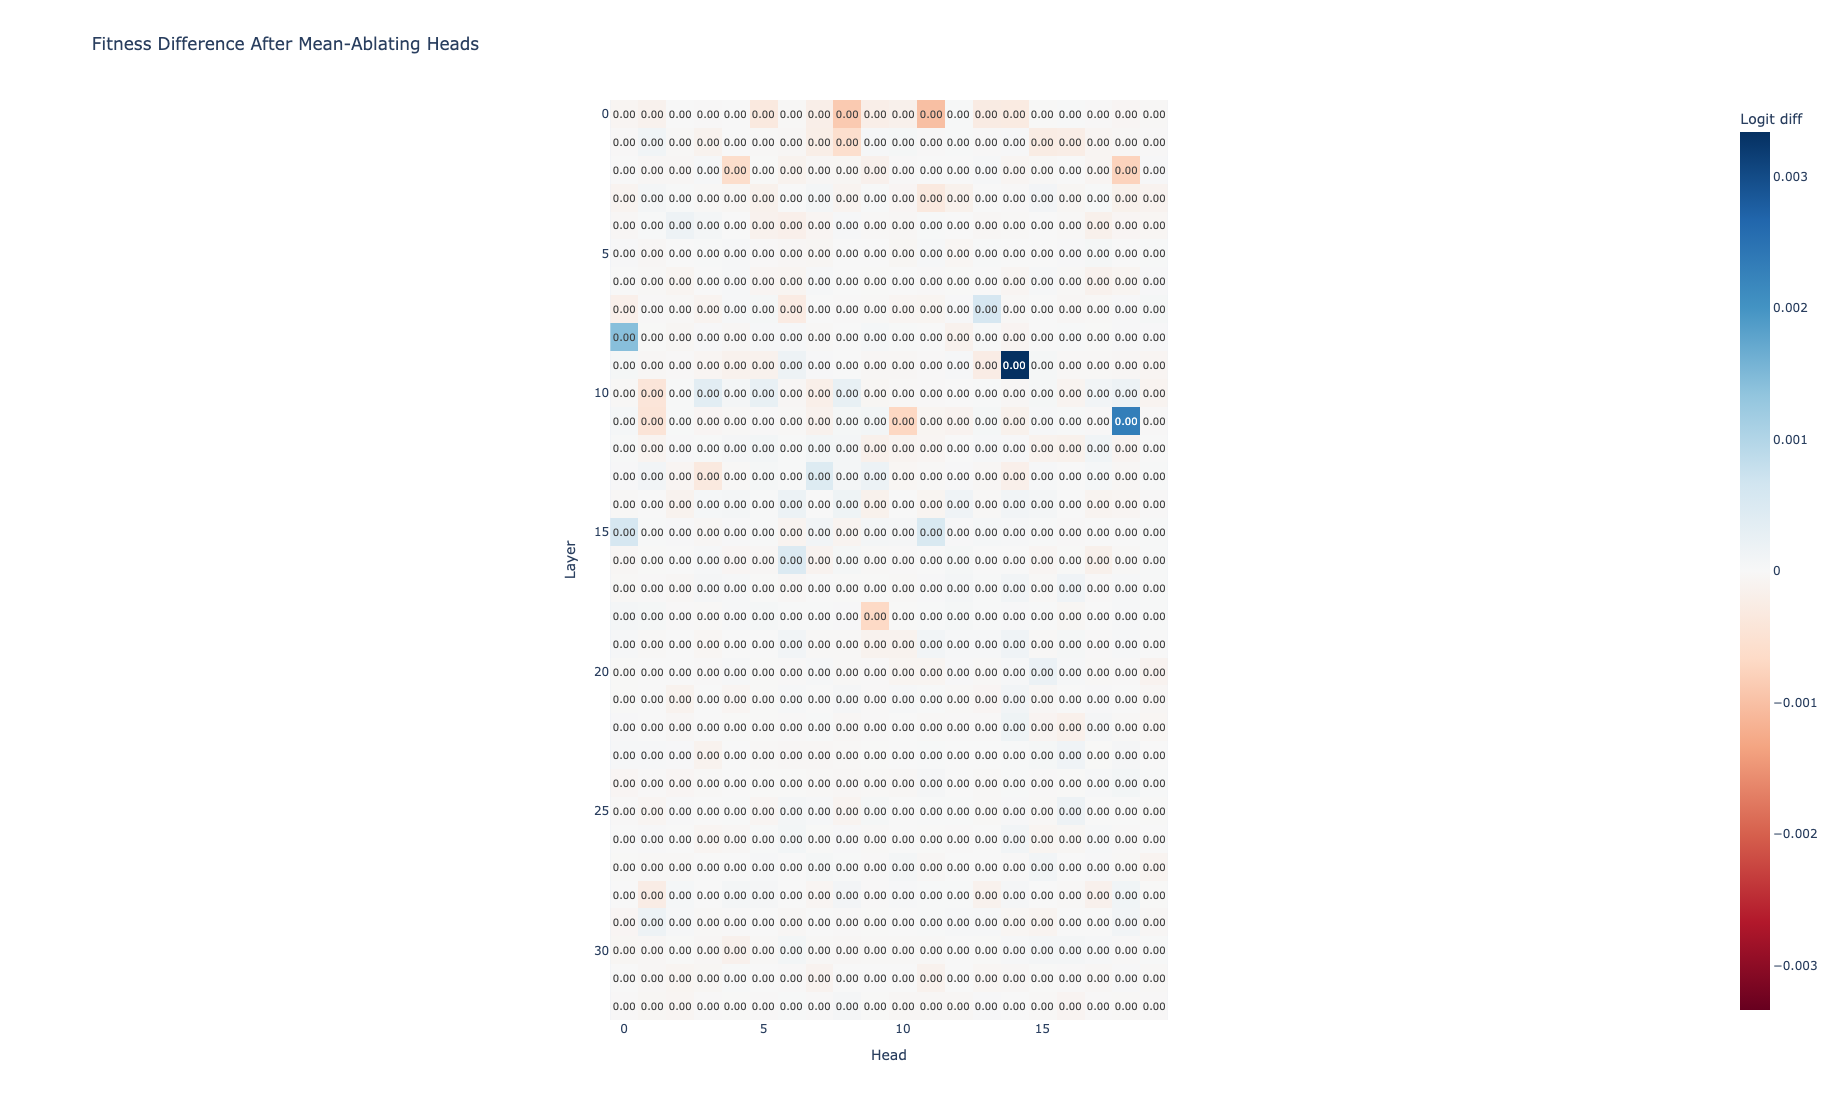

In [40]:
imshow(
    ablation_scores,
    labels={"x": "Head", "y": "Layer", "color": "Logit diff"},
    title="Fitness Difference After Mean-Ablating Heads",
    text_auto=".2f",
    width=800,
    height=1100,
)